# Image Classification ML Assignment (PART 3)
Part 3: Create a team, get inspired and try a new approach to your model (Due March 6)
- Have a group meeting and record your meeting with audio or video (you can record with zoom!)
    - Start by discussing part 2 of the assignment:
        - What approaches you each took to change the ML model in part 2
        - What are similarities and differences between your approaches 
        - What types of changes improved model performance
        - What types of changes made model performance worse
        - Based on the whole group's work, what would y'all want to do next in terms of model optimization?
    - Next, look at code and approaches from the [Happy Whales competition leaderboard](https://www.kaggle.com/competitions/happy-whale-and-dolphin/leaderboard).
        - Is there any strategy that someone used that you could implement? 
            - Ex: learning rate value, # epochs, transformation strategy, or more complex changes to the models
        - Are there strategies that you are interested in learning about?
    - Lastly, make a plan for 1 more round of model optimization
        - Assign each member something to attempt for training the model. Use your cumulative experience to decide the most important things to test. 
        - Group members can make as small as changing the value for a parameter or as big as changing the model.
- Have each member complete their test
- Share results with each other
- Write a 1-3 paragraph summary on your group's attempts and recommendations moving forward
- For Part 3: Turn in the audio/video recording of the group meeting, each member's code (uploaded to their original git repo), and the team's 1-3 paragraph summary over canvas.

### Data
- Species = you will classify images by species (gray, killer, beluga, humpback, false killer, and common dolphin)
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species

### Set up (previously part 1)

In [1]:
## Importing packages - Please DO NOT alter this box ##
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data.sampler import WeightedRandomSampler
torch.manual_seed(0)

from captum.attr import IntegratedGradients
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

import torchvision
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import os
import imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import binary_erosion
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

import wandb #comment this out if you are not using weights and biases
import random #comment this out if you are not using weights and biases

# Set device to cuda if it's available otherwise default to "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Loading in the dataset

In [2]:
images = "/projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species"

In [3]:
# We must turn our images into tensors, resize, and normalize them 
# We can also add additional transformations to images 
transform = transforms.Compose([transforms.ToTensor(), 
                                #We will start with a model called Resnet18 that is optimized for 224x224 images
                                #It is set to a very SMALL size initially so the model will train fast in class
                                transforms.Resize([32,32]),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences)
                               ])
all_images = datasets.ImageFolder(images, transform)
print(all_images)

Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


<font color='magenta'>What is the purpose(s) of transforming image data? (2 pts)

Transforming image data turns the pixels in images into tensors, which are multi dimensional numerical arrays. This standardizes images and tensors can then be implemented in neural networks for machine learning and model generalization.

<font color='green'>The below code completes the image transformations as coded in the above box.

In [4]:
all_images = datasets.ImageFolder(images, transform )
print(len(all_images))
print(all_images)

2794
Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


Our classification labels will be converted to indices, we can determine which indices is which label using the below code

In [5]:
print(all_images.class_to_idx)

{'beluga': 0, 'common_dolphin': 1, 'false_killer_whale': 2, 'fin_whale': 3, 'gray_whale': 4, 'humpback_whale': 5}


<font color='green'>The below function is used to randomly select dataset images to evaluate how the transformations altered the images.

In [6]:
## ADD YOUR TRANSFORMATION HERE
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform )

### Creating datasets used in training and testing

After loading in the data, we separate the data into training, validation, and testing datasets. The training data is inputted into the model during the training phase, and the model's predictions from this data is used to modulate the weights of the model. The validation data is used while the model trains, but the model is in a evaluation rather than training mode. The validation data gives us a real time view on how accurately the model is predicting our labels. The testing data is used after the model has completed training and tells us how successful our model will be with a novel dataset.

Once creating these 3 datasets, we prepare dataloaders which are used to load the images into our models. These images are loaded in batches into the model (a parameter called batch size). Because our dataset is imbalanced, we use a weighted random sampler to select images for our batches in the dataloader. Therefore to create our dataloader, we start by creating a function to get weights, calculating weights, initiating our weighted random sampler, and then creating our dataloaders.

<font color='green'>The below code eastablishes the data split between training, validation, and testing.

In [7]:
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - (train_size + val_size)
print(train_size, val_size, test_size)
assert train_size + val_size + test_size == len(all_images)

1955 419 420


In [8]:
train_set, val_set, test_set = torch.utils.data.random_split(all_images, [train_size, val_size, test_size])

<font color='green'>The below function is used to get weights for the image classes.

In [9]:
def _get_weights(subset,full_dataset):
    ys = np.array([y for _, y in subset])
    counts = np.bincount(ys)
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class:")
    for c, n, w in zip(full_dataset.classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")
        
    return weights

In [11]:
train_weights = _get_weights(train_set,all_images)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class:
	beluga:	n=465	weight=0.002150537634408602
	common_dolphin:	n=50	weight=0.02
	false_killer_whale:	n=716	weight=0.0013966480446927375
	fin_whale:	n=116	weight=0.008620689655172414
	gray_whale:	n=44	weight=0.022727272727272728
	humpback_whale:	n=564	weight=0.0017730496453900709


In [12]:
train_loader = DataLoader(train_set, batch_size=48, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=48, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=48, drop_last=True, shuffle=True)

### Picking hyperparameters

We can set a few hyperparameters that we decide and can tune. These include:

- Learning rate = how much to update our model's parameters at each batch/epoch
- batch size = the number of data samples to pass through the network before updating it
    - If you change the batchsize below, make sure you ALSO change it in the commands above for the DataLoader
- Number of epochs = # of times to iterate over the dataset in model training

In [13]:
learning_rate=1e-4
batchsize=48
epochs=5

### Training our model

<font color='green'>The below code builds the residual blocks that ResNet18 uses in the model.

In [14]:
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    # Initializing method for the basic block (It's OOP!)
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

<font color='green'>The below code builds and initializes the ResNet18 model.

In [15]:
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

## PART 3, TESTING MODEL CHANGES

After meeting with my group, we decided to run new models with pre-trained weights to improve validation accuracy and test effects of the following changes:

learning rate
batch size
epochs
transformation
I'm going to be testing the learning rate

Dataset being used is still species

In [20]:
batchsize = 48
learning_rate=1e-4 # changed from 1e-3
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [21]:
## Getting our model and transferring it to the GPU
from torchvision.models import ResNet18_Weights
model = torchvision.models.resnet18(weights='DEFAULT', progress = True).to(device)
model.fc = nn.Linear(model.fc.in_features, 6)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
wandb.login()

True

In [23]:
wandb.init(
    project="BGMP_HappyWhale",
    name="Thejes-HappyWhale-SpeciesDataset-pretrained_learningrate_mod1",
    config={"learning rate":.0001, # TESTING LR
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}
) 

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/5] | Batch #1 | Batch Accuracy 12.50%
Epoch [1/5] | Batch #2 | Batch Accuracy 23.96%
Epoch [1/5] | Batch #3 | Batch Accuracy 33.33%
Epoch [1/5] | Batch #4 | Batch Accuracy 39.58%
Epoch [1/5] | Batch #5 | Batch Accuracy 47.08%
Epoch [1/5] | Batch #6 | Batch Accuracy 53.12%
Epoch [1/5] | Batch #7 | Batch Accuracy 59.23%
Epoch [1/5] | Batch #8 | Batch Accuracy 62.50%
Epoch [1/5] | Batch #9 | Batch Accuracy 65.97%
Epoch [1/5] | Batch #10 | Batch Accuracy 68.54%
Epoch [1/5] | Batch #11 | Batch Accuracy 70.83%
Epoch [1/5] | Batch #12 | Batch Accuracy 72.74%
Epoch [1/5] | Batch #13 | Batch Accuracy 74.36%
Epoch [1/5] | Batch #14 | Batch Accuracy 75.74%
Epoch [1/5] | Batch #15 | Batch Accuracy 76.67%
Epoch [1/5] | Batch #16 | Batch Accuracy 77.73%
Epoch [1/5] | Batch #17 | Batch Accuracy 79.04%
Epoch [1/5] | Batch #18 | Batch Accuracy 79.75%
Epoch [1/5] | Batch #19 | Batch Accuracy 80.59%
Epoch [1/5] | Batch #20 | Batch Accuracy 81.35%
Epoch [1/5] | Batch #21 | Batch Accuracy 81.75%
E

train_loss,█▂▁▁▁
validation_accuracy,▁▇▆▅█
validation_loss,█▃▂▂▁
train_loss,0.00556
validation_accuracy,98.69792
validation_loss,0.03869


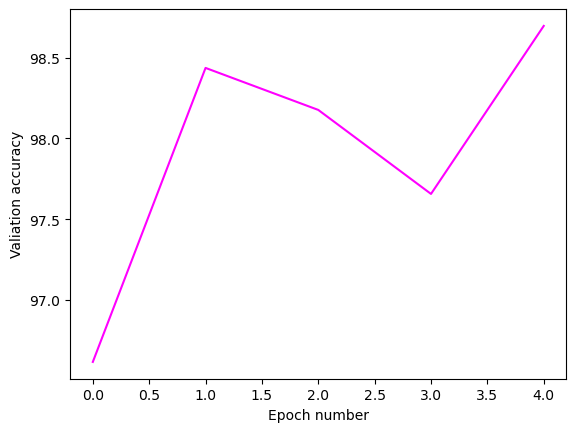

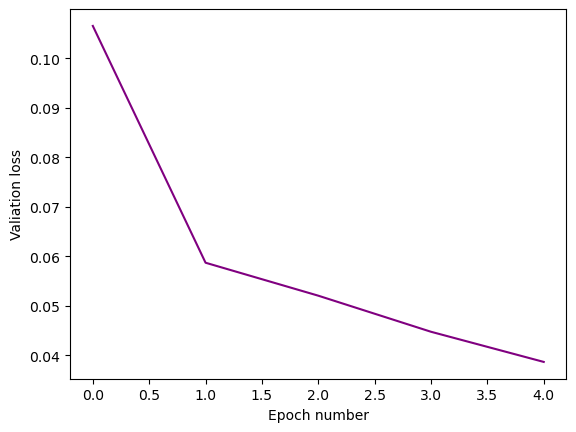

[5 2 0 2 0 2 5 2 3 0 5 3 5 5 2 5 3 2 5 2 2 5 2 5 5 2 5 2 5 5 0 0 0 4 1 2 2
 2 5 5 5 3 2 5 2 3 2 5 2 2 0 5 2 3 3 5 2 0 2 2 0 0 0 2 0 0 5 2 0 2 5 5 3 2
 5 0 0 5 5 2 4 5 5 2 2 2 0 5 5 0 2 0 0 2 0 2 2 5 2 5 5 4 0 0 2 0 2 0 2 0 5
 0 3 0 0 0 2 2 5 1 2 5 2 3 4 0 5 2 3 0 2 5 0 5 0 0 0 5 5 5 2 5 0 2 5 0 3 2
 5 2 5 2 2 2 0 2 5 0 0 0 0 5 0 2 5 2 5 2 0 5 2 2 2 5 2 5 5 5 5 5 5 0 3 5 0
 3 5 5 4 2 5 2 5 2 2 2 2 5 2 2 2 5 2 2 5 2 2 2 0 1 5 5 5 0 2 5 5 0 2 2 2 2
 2 2 5 2 2 5 1 2 2 2 3 0 0 5 5 4 0 5 2 2 5 0 4 5 4 5 2 0 2 2 5 2 5 0 5 0 2
 3 2 5 0 0 2 5 0 2 0 2 0 1 0 2 2 5 2 5 2 3 2 5 2 5 5 0 2 2 2 4 5 5 5 5 0 0
 0 5 2 0 0 5 2 3 2 0 3 5 2 5 0 2 4 2 2 2 2 2 3 0 1 2 0 2 5 2 5 5 2 5 3 0 5
 3 2 2 5 2 0 3 5 2 0 0 0 1 1 2 5 2 2 2 0 5 2 3 2 2 0 0 2 0 3 2 2 2 2 4 5 2
 2 0 2 5 0 2 0 2 2 2 0 2 2 5 0 0 0 2 2 2 5 0 2 2 3 2 0 0 0 0 2 2 0 5 0 4 0
 3 2 5 2 5 2 2 5 5 0 2 2 2]


/tmp/ipykernel_133864/1117181874.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


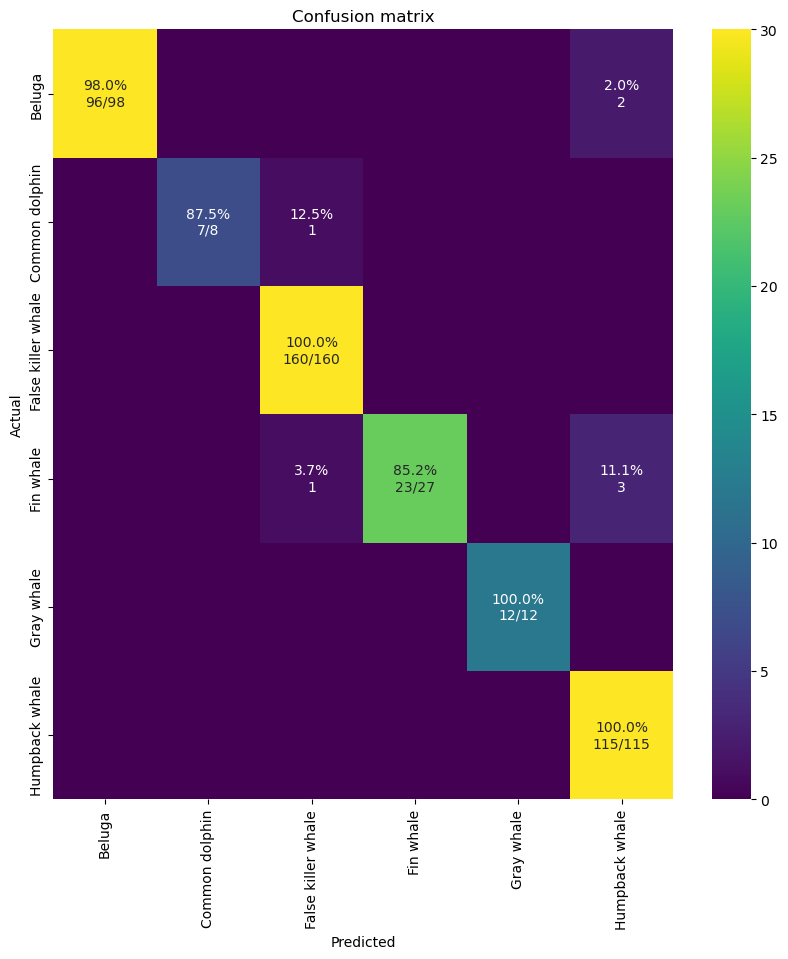

In [26]:
plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()

# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x[None]
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

# Plot confusion matrix 
# orginally from Runqi Yang; 
# see https://gist.github.com/hitvoice/36cf44689065ca9b927431546381a3f7
def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")  

The validation accuracy is much better using the pretrained weights than the random weights I used during part 2! My best model previously was at 72.14% and this model is at 98.7%. The pretrained weights were able to extract meaningful features from the whale images which improved validation accuracy. 

I'm curious to see if finetuning the learning rate will improve this slightly, although at 98.7% accuracy there's small room for improvement so any additional learning rate adjustments may decrease the accuracy.

In [30]:
batchsize = 48
learning_rate=5e-5 # changed from 1e-4
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

## Getting our model and transferring it to the GPU
from torchvision.models import ResNet18_Weights
model = torchvision.models.resnet18(weights='DEFAULT', progress = True).to(device)
model.fc = nn.Linear(model.fc.in_features, 6)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.init(
    project="BGMP_HappyWhale",
    name="Thejes-HappyWhale-SpeciesDataset-pretrained_learningrate_mod2",
    config={"learning rate":.00005, # TESTING LR, decreased it slightly
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 5, "batch_size":48}
) 

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/5] | Batch #1 | Batch Accuracy 22.92%
Epoch [1/5] | Batch #2 | Batch Accuracy 29.17%
Epoch [1/5] | Batch #3 | Batch Accuracy 36.11%
Epoch [1/5] | Batch #4 | Batch Accuracy 40.62%
Epoch [1/5] | Batch #5 | Batch Accuracy 45.42%
Epoch [1/5] | Batch #6 | Batch Accuracy 51.74%
Epoch [1/5] | Batch #7 | Batch Accuracy 55.06%
Epoch [1/5] | Batch #8 | Batch Accuracy 57.29%
Epoch [1/5] | Batch #9 | Batch Accuracy 60.42%
Epoch [1/5] | Batch #10 | Batch Accuracy 62.50%
Epoch [1/5] | Batch #11 | Batch Accuracy 63.26%
Epoch [1/5] | Batch #12 | Batch Accuracy 64.93%
Epoch [1/5] | Batch #13 | Batch Accuracy 66.19%
Epoch [1/5] | Batch #14 | Batch Accuracy 68.45%
Epoch [1/5] | Batch #15 | Batch Accuracy 69.03%
Epoch [1/5] | Batch #16 | Batch Accuracy 69.92%
Epoch [1/5] | Batch #17 | Batch Accuracy 70.71%
Epoch [1/5] | Batch #18 | Batch Accuracy 71.88%
Epoch [1/5] | Batch #19 | Batch Accuracy 72.81%
Epoch [1/5] | Batch #20 | Batch Accuracy 73.44%
Epoch [1/5] | Batch #21 | Batch Accuracy 74.31%
E

train_loss,█▂▁▁▁
validation_accuracy,▁▆███
validation_loss,█▄▂▁▁
train_loss,0.0194
validation_accuracy,97.65625
validation_loss,0.05986


With the slightly decreased learning rate (5e-5) the final validation accuracy at epoch 5 decreased from the previous model (97.66% vs 98.7%). It hit a plateau during the last three epochs so maybe the learning rate is too small enough for the model to fully converge in 5 epochs. This model may be improved if the epochs were increased.

Out of curiosity, I'm going to increase the epoch size but maintain the same learning rate as the first model I tested.

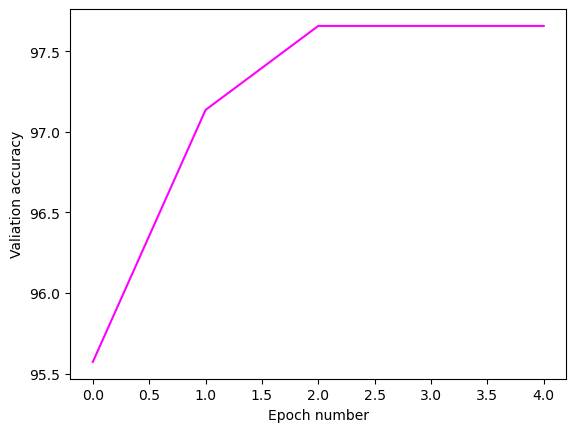

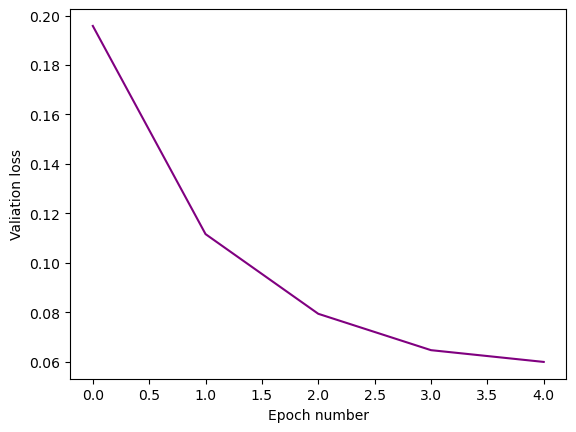

/tmp/ipykernel_133864/1117181874.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


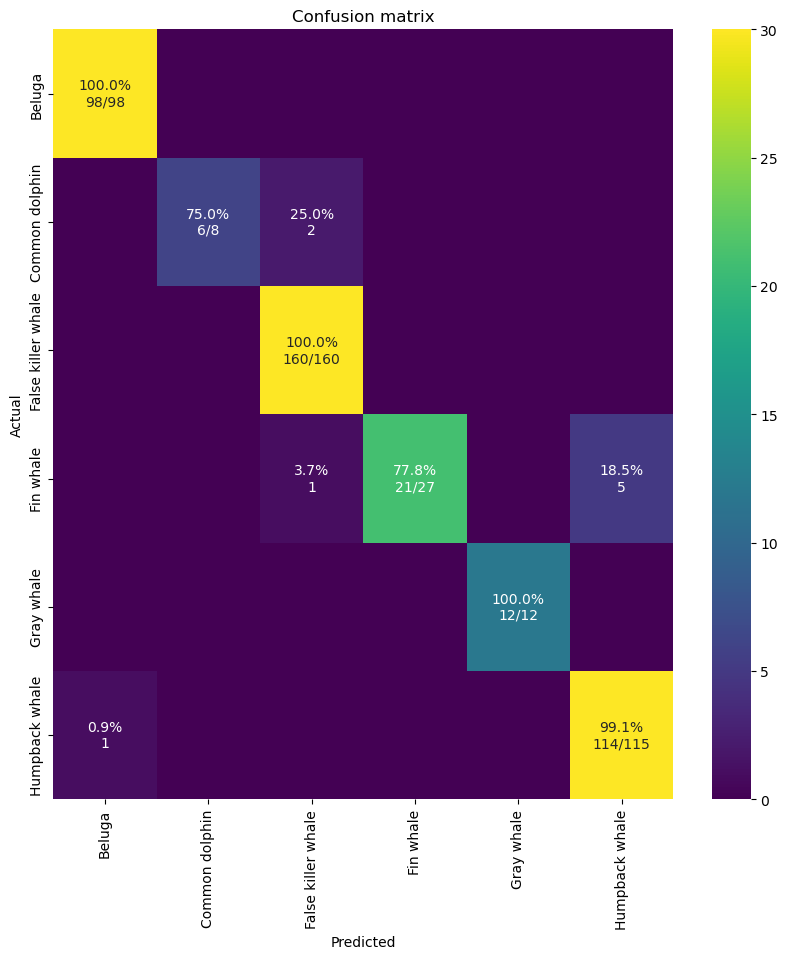

In [31]:
plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix") 

In [32]:
batchsize = 48
learning_rate=1e-4 # changed from 1e-4
epochs=8

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

## Getting our model and transferring it to the GPU
from torchvision.models import ResNet18_Weights
model = torchvision.models.resnet18(weights='DEFAULT', progress = True).to(device)
model.fc = nn.Linear(model.fc.in_features, 6)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.init(
    project="BGMP_HappyWhale",
    name="Thejes-HappyWhale-SpeciesDataset-pretrained_learningrate_epochs_mod3",
    config={"learning rate":.0001, # TESTING LR, changed to what was in mod1
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 8, "batch_size":48} # increased epochs to 8
) 

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/8] | Batch #1 | Batch Accuracy 16.67%
Epoch [1/8] | Batch #2 | Batch Accuracy 22.92%
Epoch [1/8] | Batch #3 | Batch Accuracy 31.25%
Epoch [1/8] | Batch #4 | Batch Accuracy 42.71%
Epoch [1/8] | Batch #5 | Batch Accuracy 51.25%
Epoch [1/8] | Batch #6 | Batch Accuracy 55.21%
Epoch [1/8] | Batch #7 | Batch Accuracy 58.63%
Epoch [1/8] | Batch #8 | Batch Accuracy 62.76%
Epoch [1/8] | Batch #9 | Batch Accuracy 65.74%
Epoch [1/8] | Batch #10 | Batch Accuracy 68.54%
Epoch [1/8] | Batch #11 | Batch Accuracy 69.89%
Epoch [1/8] | Batch #12 | Batch Accuracy 71.53%
Epoch [1/8] | Batch #13 | Batch Accuracy 73.24%
Epoch [1/8] | Batch #14 | Batch Accuracy 74.70%
Epoch [1/8] | Batch #15 | Batch Accuracy 75.83%
Epoch [1/8] | Batch #16 | Batch Accuracy 76.56%
Epoch [1/8] | Batch #17 | Batch Accuracy 77.82%
Epoch [1/8] | Batch #18 | Batch Accuracy 78.82%
Epoch [1/8] | Batch #19 | Batch Accuracy 79.71%
Epoch [1/8] | Batch #20 | Batch Accuracy 80.31%
Epoch [1/8] | Batch #21 | Batch Accuracy 80.95%
E

train_loss,█▂▁▁▁▁▁▁
validation_accuracy,▁▂▂█▆▅▃▅
validation_loss,█▄▄▁▃▃▂▄
train_loss,0.00274
validation_accuracy,97.91667
validation_loss,0.05611


Setting learning rate to 1e-4 and increasing the epochs to 8 did not improve the validation accuracy compared to the first model (97.9% vs 98.7%). This suggests that the model already convered in the first model at 5 epochs and additional training led to validation loss. With the pretrained weights, the model converges quickly so longer training is not beneficial.

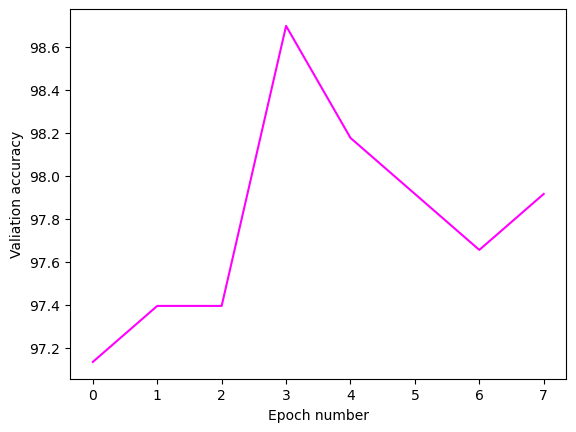

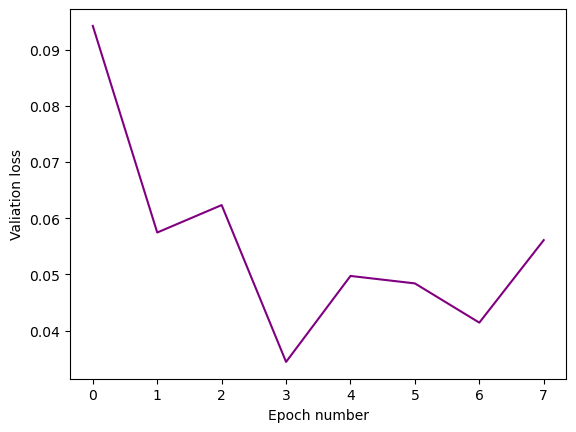

/tmp/ipykernel_133864/1117181874.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


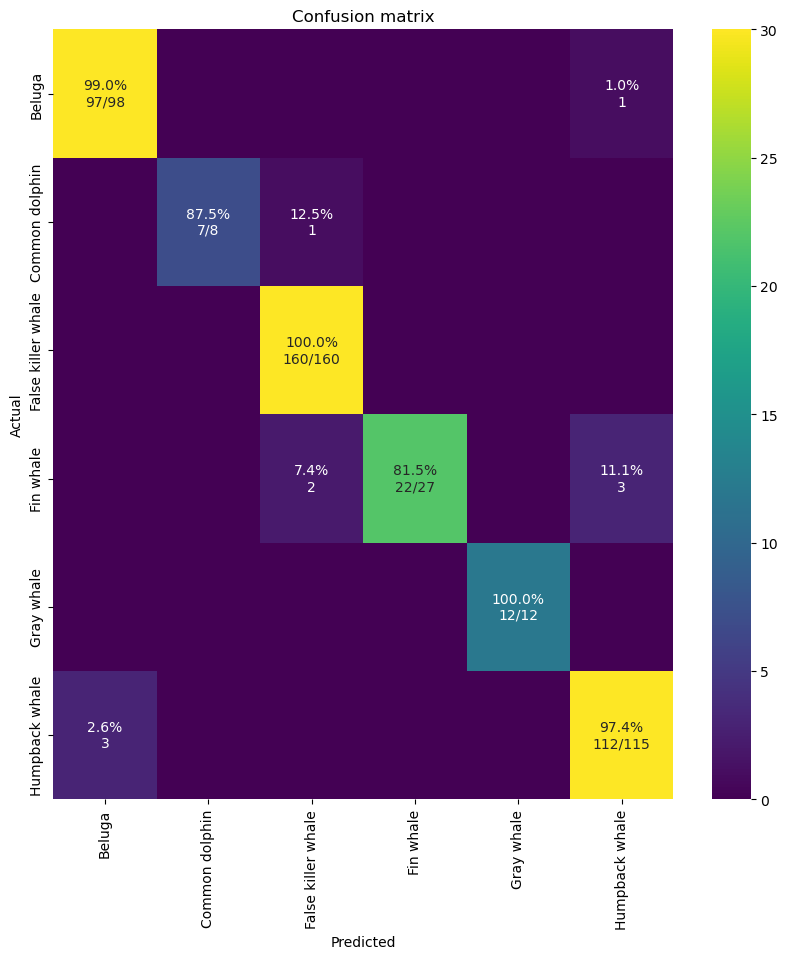

In [35]:
plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")